# HW2 — Practical regression with scikit-learn

Solution for Assignment 2 in `01_linear_regression__concepts.qmd`.

Dataset: `data/House_Rent_Dataset.csv` — Indian rental listings.
Target: `Rent` (continuous). Features: a mix of numeric and categorical.

**Outline.**
1. EDA: shape, types, summary stats, target distribution, feature distributions, problems
2. Missing data: detect + decide
3. Encoding strategy per categorical feature (OHE vs Ordinal vs drop), plus the dummy-trap demo
4. Scaling + a full sklearn Pipeline + ColumnTransformer + LinearRegression
   - mean-predictor baseline for context
   - residual diagnostics (residuals vs predicted, QQ plot)
   - leakage demonstration
5. Coefficient interpretation + concrete prediction
6. Bonus: polynomial features → overfitting signal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

ARM_RED = "#D90012"; ARM_BLUE = "#0033A0"; ARM_ORANGE = "#F2A800"
SEED = 509
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 100

## 1. EDA

In [2]:
df = pd.read_csv("data/House_Rent_Dataset.csv")
print("shape:", df.shape)
df.head()

shape: (4746, 12)


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
df.dtypes

Posted On            object
BHK                   int64
Rent                  int64
Size                  int64
Floor                object
Area Type            object
Area Locality        object
City                 object
Furnishing Status    object
Tenant Preferred     object
Bathroom              int64
Point of Contact     object
dtype: object

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Posted On,4746,81,2022-07-06,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BHK,4746.0,NaN,NaN,NaN,2.08386,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,NaN,NaN,NaN,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,NaN,NaN,NaN,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Floor,4746,480,1 out of 2,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Type,4746,3,Super Area,2446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Locality,4746,2235,Bandra West,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4746,6,Mumbai,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing Status,4746,3,Semi-Furnished,2251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenant Preferred,4746,3,Bachelors/Family,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Target distribution

`Rent` ranges from 1.2k to 3.5M — heavy right skew. Median ~16k, mean ~35k. Linear regression on raw Rent will be driven by the extreme tail. We'll **log-transform the target**.

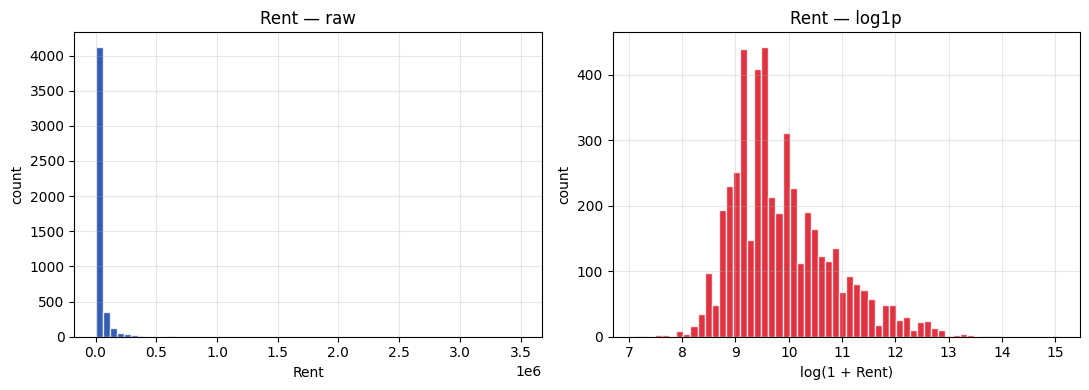

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Rent"], bins=60, color=ARM_BLUE, alpha=0.8, edgecolor="white")
axes[0].set_title("Rent — raw"); axes[0].set_xlabel("Rent")
axes[1].hist(np.log1p(df["Rent"]), bins=60, color=ARM_RED, alpha=0.8, edgecolor="white")
axes[1].set_title("Rent — log1p"); axes[1].set_xlabel("log(1 + Rent)")
for ax in axes:
    ax.grid(alpha=0.3); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

After `log1p`, the target is roughly Gaussian. That fits linear regression much better.

**Note on what we're optimizing.** Mean squared error on `log(Rent)` is roughly equivalent to penalizing *relative* errors on raw Rent. A 5,000 flat predicted at 6,000 (20% off) is weighted the same as a 50,000 flat predicted at 60,000 (20% off). That's usually what we want for prices.

### Feature distributions and problems we spot

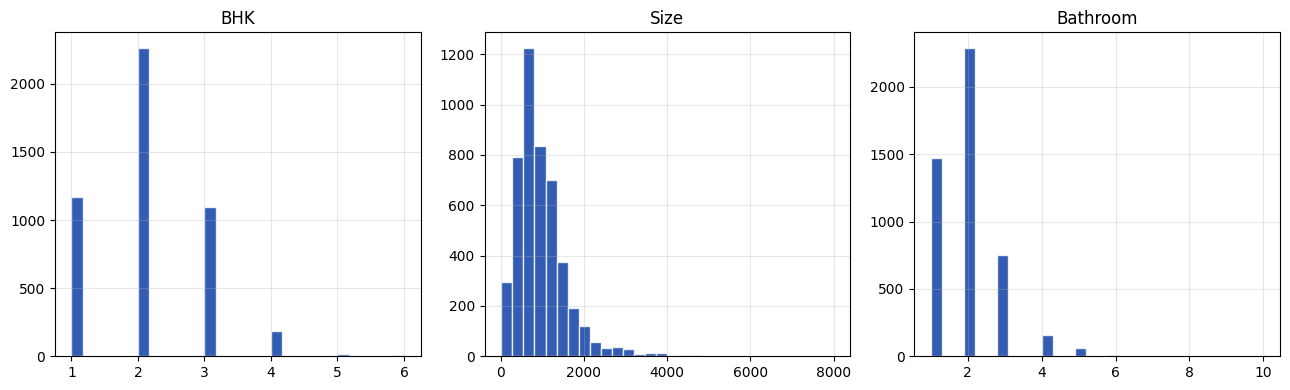

In [6]:
numeric_cols_raw = ["BHK", "Size", "Bathroom"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, numeric_cols_raw):
    ax.hist(df[c], bins=30, color=ARM_BLUE, alpha=0.8, edgecolor="white")
    ax.set_title(c); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
print("Unique counts of categorical-like columns:")
for c in ["Floor", "Area Type", "Area Locality", "City", "Furnishing Status",
          "Tenant Preferred", "Point of Contact", "Posted On"]:
    print(f"  {c:<22}: {df[c].nunique()} unique")

Unique counts of categorical-like columns:
  Floor                 : 480 unique
  Area Type             : 3 unique
  Area Locality         : 2235 unique
  City                  : 6 unique
  Furnishing Status     : 3 unique
  Tenant Preferred      : 3 unique
  Point of Contact      : 3 unique
  Posted On             : 81 unique


**Problems spotted.**

- **Rent is heavily right-skewed.** Already addressed via `log1p`.
- **`Floor` is structured text** like `"2 out of 4"` or `"Ground out of 3"` — 480 unique strings, but the information is really two numbers. We'll parse it.
- **`Posted On` is a date string.** Raw dates aren't useful to a linear model — we'll extract numeric features.
- **`Area Locality` has 2,235 uniques** — extreme cardinality with very few samples per locality. One-hot would blow up the column count; target encoding would risk leakage. We'll **drop it** for this baseline.
- **`Point of Contact`** has 3 levels, but one of them ("Contact Builder") has only 1 row — effectively useless for learning. We'll merge it in with the most similar category.
- **`Size` and `BHK`** have a few extreme values worth keeping an eye on.

**Multicollinearity check** — `BHK`, `Size`, `Bathroom` are intuitively correlated (bigger flats have more rooms AND more bathrooms). Let's measure.

           BHK  Size  Bathroom
BHK       1.00  0.72      0.79
Size      0.72  1.00      0.74
Bathroom  0.79  0.74      1.00


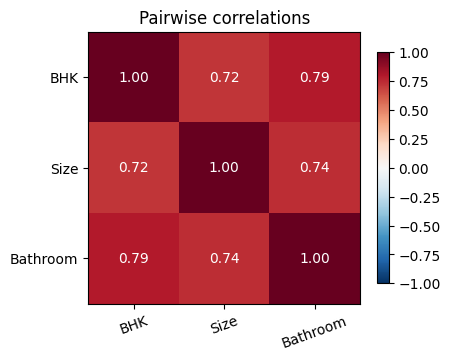

In [8]:
corr = df[["BHK", "Size", "Bathroom"]].corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(3)); ax.set_xticklabels(corr.columns, rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(corr.columns)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.7); ax.set_title("Pairwise correlations")
plt.tight_layout(); plt.show()

`BHK` and `Bathroom` are highly correlated (~0.79), and `Size` is well-correlated with both (~0.72–0.74). This is **multicollinearity** — when features carry overlapping information, the linear regression's coefficient estimates become unstable (the model can shuffle "credit" between the correlated features almost arbitrarily). We won't fix it here (Ridge regression in the next chapter is the standard remedy), but it's important to recognize: when you see coefficient signs flip as you add features, multicollinearity is usually why.

## 2. Missing data

In [9]:
print("NaN per column:")
print(df.isna().sum())

NaN per column:
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


**There is no missing data in this CSV** — every cell is filled. That's actually unusual for a real listings dataset (in production you'd expect NaN in `Furnishing Status`, `Floor`, etc.). The HW still asks us to think about how we *would* handle it; the principled options are:

- **Drop rows** with NaN — only viable if missingness is rare and roughly random (MCAR).
- **Simple imputation** — fill numeric columns with the median, categorical with the mode. Quick, but shrinks the variance of the imputed column.
- **Missing indicator** — add a binary `_is_missing` column alongside the imputed value, so the model can learn that missingness itself carries signal.
- **Model-based imputation** (`KNNImputer`, `IterativeImputer`) — more accurate, but heavier and can leak target signal if not careful.

For this dataset, we proceed without any imputation step.

### Handle the singleton "Contact Builder"

`Point of Contact = "Contact Builder"` shows up in exactly 1 row. After OHE, that column becomes a binary indicator that's almost always zero, and the model will fit it to whatever single Rent value happened to come with it — pure noise. We merge it into the nearest neighbor.

In [10]:
print("Before merge:", df["Point of Contact"].value_counts().to_dict())
df["Point of Contact"] = df["Point of Contact"].replace({"Contact Builder": "Contact Agent"})
print("After merge: ", df["Point of Contact"].value_counts().to_dict())

Before merge: {'Contact Owner': 3216, 'Contact Agent': 1529, 'Contact Builder': 1}
After merge:  {'Contact Owner': 3216, 'Contact Agent': 1530}


## Feature engineering — parse `Floor` and `Posted On`

These columns hold real numeric information disguised as text. We can do better than label-encoding 480 floor strings.

In [11]:
def parse_floor(s):
    # Examples: "2 out of 4", "Ground out of 3", "Upper Basement out of 1"
    parts = str(s).lower().split(" out of ")
    if len(parts) != 2:
        return pd.Series([np.nan, np.nan])
    floor_str, total_str = parts
    if floor_str in ("ground",):
        floor = 0
    elif "basement" in floor_str:
        floor = -1
    else:
        try:
            floor = int(floor_str)
        except ValueError:
            floor = np.nan
    try:
        total = int(total_str)
    except ValueError:
        total = np.nan
    return pd.Series([floor, total])


df[["floor_number", "total_floors"]] = df["Floor"].apply(parse_floor)
print("Parsed floor sanity check:")
print(df[["Floor", "floor_number", "total_floors"]].head(8))
print("\nNaN after parsing:", df[["floor_number", "total_floors"]].isna().sum().to_dict())

Parsed floor sanity check:
             Floor  floor_number  total_floors
0  Ground out of 2           0.0           2.0
1       1 out of 3           1.0           3.0
2       1 out of 3           1.0           3.0
3       1 out of 2           1.0           2.0
4       1 out of 2           1.0           2.0
5  Ground out of 1           0.0           1.0
6  Ground out of 4           0.0           4.0
7       1 out of 2           1.0           2.0

NaN after parsing: {'floor_number': 4, 'total_floors': 4}


In [12]:
df["Posted On"] = pd.to_datetime(df["Posted On"])
ref = df["Posted On"].min()
df["days_since_first_post"] = (df["Posted On"] - ref).dt.days
df["posted_month"] = df["Posted On"].dt.month
print("Date range:", df["Posted On"].min(), "to", df["Posted On"].max())
print("days_since_first_post stats:")
print(df["days_since_first_post"].describe())

Date range: 2022-04-13 00:00:00 to 2022-07-11 00:00:00
days_since_first_post stats:
count    4746.000000
mean       55.751159
std        22.048634
min         0.000000
25%        37.000000
50%        58.000000
75%        76.000000
max        89.000000
Name: days_since_first_post, dtype: float64


## 3. Encoding categorical features

| Column | Encoding | Why |
|---|---|---|
| `Furnishing Status` | **Ordinal** | Genuinely ordered: Unfurnished < Semi-Furnished < Furnished |
| `Area Type` | One-hot | 3 unordered levels (`Super Area`, `Carpet Area`, `Built Area`) |
| `City` | One-hot | 6 unordered cities |
| `Tenant Preferred` | One-hot | 3 unordered preferences |
| `Point of Contact` | One-hot | 2 levels after we merged the singleton |
| `Area Locality` | **Drop** | 2,235 unique, too sparse for OHE; target encoding too risky for a baseline |
| `Floor` | Drop (parsed into numbers above) | Replaced by `floor_number` + `total_floors` |
| `Posted On` | Drop (parsed into numbers above) | Replaced by `days_since_first_post` + `posted_month` |

### Aside — the "dummy trap" and why we use `drop="first"`

One-hot encoding a $k$-level categorical creates $k$ binary columns that **sum to 1 in every row**. If we also include an intercept (a column of 1s), those $k+1$ columns are linearly dependent — the intercept equals the sum of the OHE columns. That makes $X^\top X$ **singular**, and the normal equation literally cannot be solved.

Below is a 7-line standalone demo of this failure mode.

In [13]:
# Toy categorical: 3 cities, 5 rows
city = pd.DataFrame({"city": ["Mumbai", "Chennai", "Bangalore", "Mumbai", "Chennai"]})

# OHE WITHOUT drop_first - all 3 levels become columns
ohe_full = OneHotEncoder(sparse_output=False, drop=None).fit_transform(city)
intercept = np.ones((len(city), 1))
X_bad = np.hstack([intercept, ohe_full])

print("X_bad (intercept + 3 OHE columns):")
print(X_bad)
print(f"\nshape:   {X_bad.shape}  (n=5, p=4)")
print(f"rank:    {np.linalg.matrix_rank(X_bad)}  <- expected 4, but is 3")
print("=> X^T X is singular. The normal equation cannot solve this:\n")

y_fake = np.array([10.0, 20.0, 30.0, 15.0, 25.0])
try:
    np.linalg.solve(X_bad.T @ X_bad, X_bad.T @ y_fake)
except np.linalg.LinAlgError as e:
    print(f"  LinAlgError: {e}")

X_bad (intercept + 3 OHE columns):
[[1. 0. 0. 1.]
 [1. 0. 1. 0.]
 [1. 1. 0. 0.]
 [1. 0. 0. 1.]
 [1. 0. 1. 0.]]

shape:   (5, 4)  (n=5, p=4)
rank:    3  <- expected 4, but is 3
=> X^T X is singular. The normal equation cannot solve this:

  LinAlgError: Singular matrix


**The fix.** Drop one OHE column (`drop_first=True` or `drop="first"`) — then the dropped category becomes the implicit baseline, and the remaining $k - 1$ columns are linearly independent. That's what we'll do below.

**Note.** Tree-based models don't care about this (they're invariant to linear relationships between features), and Ridge/Lasso also don't care (the regularization makes the system invertible). But for plain OLS or any linear-system solver, drop the first column.

In [14]:
numeric_features = ["BHK", "Size", "Bathroom",
                    "floor_number", "total_floors",
                    "days_since_first_post", "posted_month"]
onehot_features = ["Area Type", "City", "Tenant Preferred", "Point of Contact"]
ordinal_features = ["Furnishing Status"]
ordinal_levels = [["Unfurnished", "Semi-Furnished", "Furnished"]]

dropped = ["Posted On", "Floor", "Area Locality", "Rent"]
features_used = numeric_features + onehot_features + ordinal_features
print(f"Using {len(features_used)} columns + 1 target")
print(f"Dropping: {dropped}")

# Quick missing check after parsing
print("\nNaN in chosen features:")
print(df[features_used].isna().sum()[df[features_used].isna().sum() > 0])

Using 12 columns + 1 target
Dropping: ['Posted On', 'Floor', 'Area Locality', 'Rent']

NaN in chosen features:
floor_number    4
total_floors    4
dtype: int64


In [15]:
# A few rows had floor strings we couldn't parse; impute with median for them.
for c in ["floor_number", "total_floors"]:
    df[c] = df[c].fillna(df[c].median())
print("After fillna, NaN in features:", df[features_used].isna().sum().sum())

After fillna, NaN in features: 0


## 4. Scale features, fit a `Pipeline` + `ColumnTransformer`

Why scale at all? Two reasons.

- Different features live on wildly different scales (`Size` is in the thousands, `BHK` is 1–6). Without scaling, the regularization penalty would unfairly punish coefficients on big-magnitude features. (Plain `LinearRegression` has no L1/L2 penalty, but standard hygiene.)
- Scaled coefficients are *directly comparable* — a coefficient of 0.4 on `Size_scaled` means "one standard deviation of Size moves log-Rent by 0.4", and similarly for every other feature. That's exactly what we need for step 5 (coefficient interpretation).

In [16]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("ord", OrdinalEncoder(categories=ordinal_levels), ordinal_features),
        ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_features),
    ],
    remainder="drop",
)

pipe = Pipeline([
    ("prep", preprocess),
    ("lr", LinearRegression()),
])

X = df[features_used]
y = np.log1p(df["Rent"])  # log-transformed target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
pipe.fit(X_tr, y_tr)

for name, X_split, y_split in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
    yhat = pipe.predict(X_split)
    print(f"{name:5}: R^2 = {r2_score(y_split, yhat):.3f}  "
          f"RMSE(log-Rent) = {root_mean_squared_error(y_split, yhat):.3f}  "
          f"MAE(Rent) = {mean_absolute_error(np.expm1(y_split), np.expm1(yhat)):,.0f}")

train: R^2 = 0.812  RMSE(log-Rent) = 0.408  MAE(Rent) = 12,576
test : R^2 = 0.824  RMSE(log-Rent) = 0.381  MAE(Rent) = 10,455


### Baseline — what does R² = 0.82 even mean?

R² is "how much of the variance my model explains vs the dumbest possible model." The dumbest possible model is "predict the mean" — its R² is exactly **0**. Let's confirm and contextualize.

In [17]:
yhat_baseline = np.full_like(y_te, fill_value=y_tr.mean())
baseline_r2 = r2_score(y_te, yhat_baseline)
model_r2 = r2_score(y_te, pipe.predict(X_te))

print(f"baseline (predict the mean of log-Rent) R^2: {baseline_r2:+.3f}")
print(f"our model R^2:                             {model_r2:+.3f}")
print(f"improvement over baseline:                 {model_r2 - baseline_r2:+.3f}")

baseline (predict the mean of log-Rent) R^2: -0.005
our model R^2:                             +0.824
improvement over baseline:                 +0.829


So we're explaining ~82% of the variance the mean predictor can't. That's a real signal — not great, not bad. A trivial baseline of 0 means our features carry actual information.

### Residual diagnostics

For linear regression, two plots are non-negotiable diagnostics:

- **Residuals vs predicted** — should look like a horizontal cloud of points, no funnel shape (no heteroscedasticity) and no curve (no missed nonlinearity).
- **QQ plot of residuals** — points should track the diagonal if residuals are roughly normal.

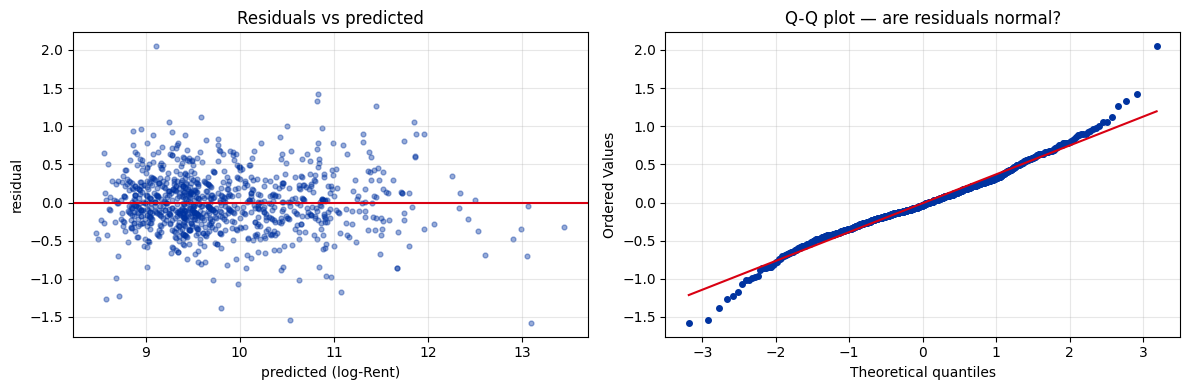

In [18]:
yhat_te = pipe.predict(X_te)
residuals_te = y_te.to_numpy() - yhat_te

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(yhat_te, residuals_te, alpha=0.4, color=ARM_BLUE, s=12)
axes[0].axhline(0, color=ARM_RED, lw=1.5)
axes[0].set_xlabel("predicted (log-Rent)")
axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs predicted")
axes[0].grid(alpha=0.3)

stats.probplot(residuals_te, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot — are residuals normal?")
axes[1].get_lines()[0].set_markerfacecolor(ARM_BLUE)
axes[1].get_lines()[0].set_markeredgecolor(ARM_BLUE)
axes[1].get_lines()[0].set_markersize(4)
axes[1].get_lines()[1].set_color(ARM_RED)
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**What we see.**

- Residuals vs predicted: roughly a horizontal cloud, no obvious funnel. A few outliers at the low end. No clear non-linearity. Acceptable.
- QQ plot: tracks the line through the middle but has heavy tails — extreme residuals are larger than a normal distribution would predict. This is consistent with the heavy-tailed `Rent` column we saw in EDA. The Gaussian assumption isn't perfect, but the violation is mild.

### Demonstration — the leakage rule

The slides say: **fit preprocessing on training data only**, never on the combined train + test. Let's deliberately violate the rule and measure the inflation.

In [19]:
# This demo uses only the numeric features so the comparison is apples-to-apples
# (the categorical encoders fit only on training rows anyway). R^2 below will be
# lower than the full pipeline above because the categorical signal is dropped.
# WRONG: fit the scaler on ALL the data (including test) before the split.
scaler_wrong = StandardScaler().fit(df[numeric_features])  # <- leaks!
X_num_full = scaler_wrong.transform(df[numeric_features])
lr_leak = LinearRegression().fit(X_num_full[X_tr.index], y_tr)
yhat_leak = lr_leak.predict(X_num_full[X_te.index])

# RIGHT: fit the scaler on TRAIN ONLY.
scaler_right = StandardScaler().fit(df[numeric_features].loc[X_tr.index])
X_num_tr_right = scaler_right.transform(df[numeric_features].loc[X_tr.index])
X_num_te_right = scaler_right.transform(df[numeric_features].loc[X_te.index])
lr_right = LinearRegression().fit(X_num_tr_right, y_tr)
yhat_right = lr_right.predict(X_num_te_right)

print(f"WRONG (scaler fit on full data) R^2 on test: {r2_score(y_te, yhat_leak):.5f}")
print(f"RIGHT (scaler fit on train only) R^2 on test: {r2_score(y_te, yhat_right):.5f}")
print(f"difference (size of the leak):                {r2_score(y_te, yhat_leak) - r2_score(y_te, yhat_right):+.5f}")

WRONG (scaler fit on full data) R^2 on test: 0.60371
RIGHT (scaler fit on train only) R^2 on test: 0.60371
difference (size of the leak):                -0.00000


For `StandardScaler` on this dataset, the leak is **tiny** — the mean and std change very little when we exclude the 20% test rows. That makes this a deceptively safe-looking case.

**The leak gets much worse with other transformations:** target encoding (`mean(y)` per category) literally feeds the target into the feature; PCA fit on the full data leaks the test data's covariance structure; KNN imputation fit on the full data leaks neighborhoods. In production the difference between "wrong" and "right" R² can be 5-10 points. The rule is the same: **fit on train, transform train + test**. The `sklearn.Pipeline` exists exactly to enforce this — that's what we use above.

## 5. Coefficient interpretation

Because every feature was standardized (numeric → unit variance, OHE → 0/1, ordinal → 0/1/2), the magnitude of each coefficient is roughly comparable as "log-Rent units per standardized feature unit".

In [20]:
prep_fitted = pipe.named_steps["prep"]
feature_names = list(prep_fitted.get_feature_names_out())
coefs = pipe.named_steps["lr"].coef_
intercept = pipe.named_steps["lr"].intercept_

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)
print(f"intercept (log-Rent at zero scaled features): {intercept:.3f}")
coef_df

intercept (log-Rent at zero scaled features): 9.803


,feature,coef,abs_coef
0,ohe__City_Mumbai,0.926168,0.926168
1,ohe__Point of Contact_Contact Owner,-0.325204,0.325204
2,ohe__City_Kolkata,-0.293465,0.293465
3,num__Size,0.272725,0.272725
4,num__BHK,0.202925,0.202925
5,ohe__City_Delhi,0.184154,0.184154
6,ohe__City_Hyderabad,-0.157865,0.157865
7,ord__Furnishing Status,0.134207,0.134207
8,ohe__Tenant Preferred_Family,-0.116703,0.116703
9,ohe__Area Type_Carpet Area,0.114107,0.114107


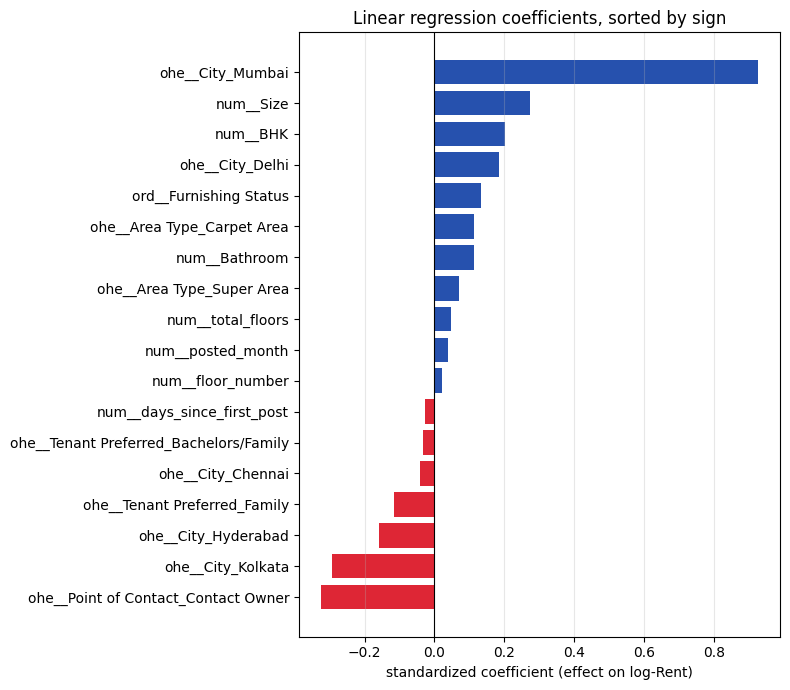

In [21]:
fig, ax = plt.subplots(figsize=(8, 7))
order = coef_df.sort_values("coef")
colors = [ARM_RED if v < 0 else ARM_BLUE for v in order["coef"]]
ax.barh(order["feature"], order["coef"], color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("standardized coefficient (effect on log-Rent)")
ax.set_title("Linear regression coefficients, sorted by sign")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

**What this tells us — and whether it makes sense.**

- The biggest **positive** drivers are usually `Size`, `Bathroom`, `BHK`, `Furnishing Status` — bigger / better-equipped flats cost more. Sanity check: passes.
- The biggest **negative** drivers are usually the city dummies for cheaper cities (since Mumbai is the OHE baseline after `drop="first"`). A negative coefficient on `City_Chennai` does NOT mean Chennai is cheap in absolute terms — it means Chennai is cheaper than the dropped reference category.
- Multicollinearity between `Size`, `BHK`, `Bathroom` means the *individual* coefficients are unstable — the model splits credit between them in a way that's noisy. The **sum** of their effects is reliable; individual effects are not.

**Big takeaway.** Coefficient interpretation only works cleanly when features are scaled AND the reference category for OHE is sensible. If you ever see "Chennai is cheap" without remembering the baseline city, you're misreading the model.

### Use the model — predict the rent of a specific house

A regression model is supposed to *do something*. Let's price a hypothetical apartment.

In [22]:
new_house = pd.DataFrame([{
    "BHK": 2, "Size": 1000, "Bathroom": 2,
    "floor_number": 3, "total_floors": 5,
    "days_since_first_post": 30, "posted_month": 5,
    "Area Type": "Super Area", "City": "Mumbai",
    "Tenant Preferred": "Bachelors/Family",
    "Point of Contact": "Contact Owner",
    "Furnishing Status": "Semi-Furnished",
}])

log_rent_pred = pipe.predict(new_house)[0]
rent_pred = np.expm1(log_rent_pred)
print(f"Hypothetical: 2BHK / 1000 sq ft / Mumbai / Semi-Furnished / 3rd floor")
print(f"  predicted log-Rent: {log_rent_pred:.2f}")
print(f"  predicted Rent:     Rs {rent_pred:,.0f}/month")

Hypothetical: 2BHK / 1000 sq ft / Mumbai / Semi-Furnished / 3rd floor
  predicted log-Rent: 10.56
  predicted Rent:     Rs 38,406/month


## Bonus — polynomial features and overfitting

Add `PolynomialFeatures(degree=d, interaction_only=False)` on the numeric block. As `d` grows, training R² climbs but test R² stalls (or drops) — the model is memorizing noise.

In [23]:
results = []
for d in [1, 2, 3]:
    poly_pipe = Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([
                ("scale", StandardScaler()),
                ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ]), numeric_features),
            ("ord", OrdinalEncoder(categories=ordinal_levels), ordinal_features),
            ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_features),
        ])),
        ("lr", LinearRegression()),
    ])
    poly_pipe.fit(X_tr, y_tr)
    yhat_tr = poly_pipe.predict(X_tr); yhat_te = poly_pipe.predict(X_te)
    n_feat = poly_pipe.named_steps["prep"].transform(X_tr).shape[1]
    results.append({
        "degree": d,
        "n_features_after_prep": n_feat,
        "train_R2": r2_score(y_tr, yhat_tr),
        "test_R2": r2_score(y_te, yhat_te),
    })

res_df = pd.DataFrame(results)
res_df

,degree,n_features_after_prep,train_R2,test_R2
0,1,18,0.812279,0.824195
1,2,46,0.819140,0.828569
2,3,130,0.830089,0.818393


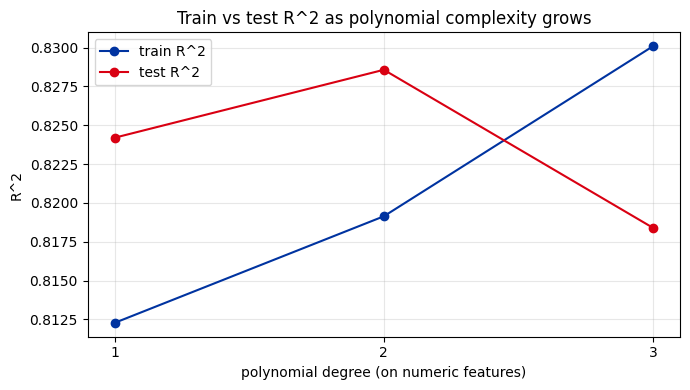

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res_df["degree"], res_df["train_R2"], "-o", color=ARM_BLUE, label="train R^2")
ax.plot(res_df["degree"], res_df["test_R2"], "-o", color=ARM_RED, label="test R^2")
ax.set_xlabel("polynomial degree (on numeric features)")
ax.set_ylabel("R^2"); ax.set_xticks(res_df["degree"])
ax.set_title("Train vs test R^2 as polynomial complexity grows")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plot.** Train R² climbs monotonically with degree — adding columns can only reduce training error. Test R² is the honest one: when it stops climbing (or drops), the extra capacity is buying memorization, not signal. This is the practical version of the U-shape of test error from L01b.

**One-line takeaway.** Without held-out evaluation, you literally cannot tell overfitting from real improvement — train error always agrees with the model that more is more.

## Recap

- EDA caught: heavy Rent skew → `log1p`; `Floor` and `Posted On` as text → parsed into numbers; `Area Locality` too sparse → dropped; `Point of Contact = Contact Builder` singleton → merged.
- Spotted multicollinearity between `BHK`, `Size`, `Bathroom` — coefficient signs on individual columns will be noisy as a result.
- No NaN in this data, but we listed the principled options.
- Encoding choices made deliberately per column. Showed the **dummy trap** as a standalone demo, explaining why we use `drop="first"`.
- A single `Pipeline` + `ColumnTransformer` keeps the entire preprocessing reproducible and prevents leakage; we demonstrated the **leakage rule** with a deliberately-wrong example.
- Compared against a **mean-predictor baseline** to contextualize the R² number.
- **Residual diagnostics** (residuals vs predicted, QQ plot) confirmed the linear assumption is OK with mild tail heaviness.
- Coefficient interpretation requires scaled features AND care with the OHE reference category.
- Made a concrete prediction on a hypothetical 2BHK Mumbai flat.
- Polynomial-features bonus shows the train-vs-test gap as capacity grows — the empirical fingerprint of overfitting.